# PRACTICAL EXAM: Data Summarization & Visualization

## Instructions
- Open Google Colab/Jupyter Notebook
- Download the iris dataset in kaggle : https://www.kaggle.com/datasets/himanshunakrani/iris-dataset
- Open the .ipynb file in Google Colab, save your own copy, complete all tasks in the provided cells, and ensure all outputs are visible before submitting. Pass as PDF or the ipynb file. filename: surname_practical

# LITTLE BACKGROUND ON THE DATASET

This dataset contains measurements of iris flowers from three different species:

Setosa
Versicolor
Virginica

Each row in the dataset represents one flower, and the columns describe its physical characteristics.

The dataset includes the following variables:

Sepal Length – length of the outer leaf (in cm)
Sepal Width – width of the outer leaf (in cm)
Petal Length – length of the inner petal (in cm)
Petal Width – width of the inner petal (in cm)
Species – type of iris flower (categorical)

# 🔹 PART 0: LOAD THE DATA (5 pts)
Load the dataset and display the first 5 rows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load .csv file
df = pd.read_csv("iris.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 🔹 PART 1: DATA UNDERSTANDING (5 pts)
Explore the dataset:
- Show column names
- Show data types
- Show number of rows and columns

In [2]:
# Show column names and data types
print(df.dtypes)

# Show number of rows and columns
print(df.shape)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object
(150, 5)


# 🔹 PART 2: DATA CLEANING CHECK (5 pts)
Check if the dataset needs cleaning. Explain your answer.

The Iris dataset from UCI/Kaggle does not need cleaning as upon inspection of the .csv file, the values are well within the data types scope and there are no missing values. Duplicate values are acceptable in this scenario as in real-world datasets, two flowers may happen to have identical measurements.

With manual inspection, all 150 rows have complete measurements for sepal length, sepal width, petal length, and petal width. It also has consistent labels where there are only three valid categories: setosa, versicolor, and virginica.


Data verification can be done with pandas to confirm there are no missing values, duplicates, or inconsistencies.

**The result below verifies this claim.**

In [3]:
# Check for missing values
print(df.isnull().sum()) # All zeros (no missing values)

# Inspect unique species labels
print(df['species'].unique()) # Three categories

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


# 🔹 PART 3: BASIC DATA SUMMARY (10 pts)
Compute the mean, minimum, and maximum for ALL numerical columns.
Then briefly explain what these values tell you about the dataset

Based on the computed table summary, the minimum and maximum values show that there are no extreme outliers and the data is well-balanced. The standard deviation is generally low with the values being under 0 across all columns with the exception of petal length.

Comparing means across features shows that petals are generally smaller but more fluctuations than sepals. Sepal width has the lowest deviation (0.43cm), while petal length has the highest (1.76cm). This may mean that petal measurements may differ more across species. Low deviation in sepal width means it contributes less to distinguishing species.

Sepal length ranges from 4.3cm to 7.9cm while sepal width ranges from 2.0cm to 4.4cm. When it comes to petal length, it ranges from 1.0cm to 6.9cm while the petal width ranges from 0.1cm to 2.5cm. These ranges show the biological limits of the flowers sampled and establishes that the data provided are uniform due to being close to the mean and having no extreme outliers within the given mean and range.

In [4]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


# 🔹 PART 4: SUMMARY TABLE (15 pts)
Group the dataset by Species and compute the average of each measurement.

In [5]:
# Group by species and compute mean of each measurement
grouped_means = df.groupby("species").mean().round(2)

print(grouped_means)

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa              5.01         3.42          1.46         0.24
versicolor          5.94         2.77          4.26         1.33
virginica           6.59         2.97          5.55         2.03


# 🔹 PART 5: HISTOGRAM (15 pts)
Create a histogram for Sepal Length.
- Add title
- Label axes

Text(0, 0.5, 'Frequency')

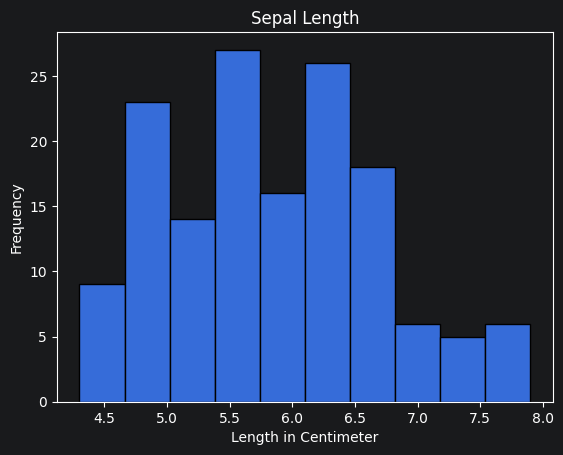

In [6]:
counts, bins, _ = plt.hist(df["sepal_length"], edgecolor="black")

plt.title("Sepal Length")
plt.xlabel("Length in Centimeter")
plt.ylabel("Frequency")

# 🔹 PART 6: FREQUENCY POLYGON (10 pts)
Create a frequency polygon for Sepal Length using a line graph.

Text(0, 0.5, 'Frequency')

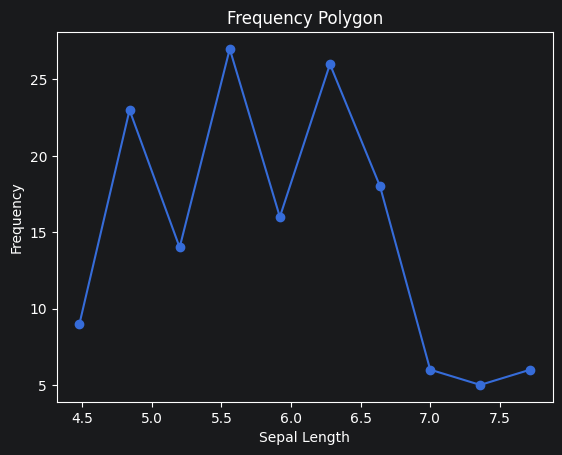

In [7]:
midpoints = (bins[:-1] + bins[1:]) / 2

plt.plot(midpoints, counts, marker="o")
plt.title("Frequency Polygon")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")

# 🔹 PART 7: SCATTERPLOT (15 pts)
Create a scatterplot:
- X = Sepal Length
- Y = Petal Length
- Color by Species

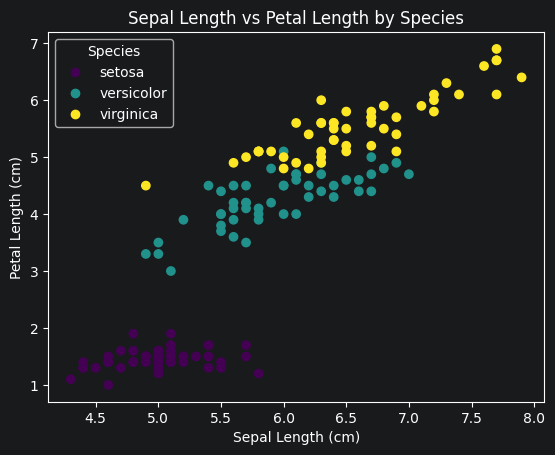

In [8]:
# Color by Species
species_codes = df["species"].astype("category").cat.codes
species_labels = df["species"].astype("category").cat.categories

# Scatterplot
scatter = plt.scatter(df["sepal_length"], df["petal_length"],c=species_codes)

# Labels
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Sepal Length vs Petal Length by Species")

# Fix legend
handles, _ = scatter.legend_elements()
plt.legend(handles, species_labels, title="Species")

plt.show()

# 🔹 PART 8: INTERPRETATION (20 pts)
Answer in mark down cell
1. Which species has the largest petal length on average?

        Virginica (marked as yellow) can be seen in the graph as the species with the largest petal in average due to being projected up-right in the graph.


2. What pattern do you observe in the scatterplot?

        In the projected scatterplot, it can be observed that there is a positive correlation with the petal length and sepal length. However, there is a cap on the minimum and maximum length per species. For instance, setosa has the smallest petal and sepal length compared to other species. It also has the largest disparity in contrast to other flower species where it did not overlap wit the other species. Versicolor is the average length in terms of petal and sepal. Its movement in the graph is mostly similar to virginica with the exception of virginica being the biggest among all species. Both of them overlap each other leaving the setosa separated.


3. Describe the distribution of at least TWO numerical features.

    Are they symmetrical, positively skewed, or negatively skewed? What does this tell you about the data?

        The petal length has negative skewness since the mean (3.76) is lower than the median (4.35). This suggests a negative skewness where the tail is towards the left. This can be seen in the scatterplot where the setosa pulls the mean downward. The distribution here can be described as bi-modal as the setosa is seperate to the distribution of versicolor and virginica.

        The sepal width is closely symmetric due to having its mean very close to its median. It also has a low standard deviation meaning that its data is clustered around each other meaning there are no extreme outliers that pull the mean.


4. Why are graphs better than tables for large datasets?

        Large datasets are notoriously difficult to analyze especially when creating a conclusion about a certain variable. Graphs solve this problem by projecting the numbers into visuals, which ultimately make it easier to interpret and create inference. Moreover, graphs makes it easier to analyze the movement, direction, or relationship between variables that would otherwise be hidden in tables. In this example, the positive relationship between petal and sepal length can be easily seen through the scatterplot which would not be possible if only analyzed through table.

